# Clausius Beta-Equilibrium `v_s^2` Postprocessing

This notebook documents the postprocessing step used to make the Clausius beta-equilibrium comparison plots easier to read.

It does **not** rerun the full Clausius scan. Instead, it starts from the stored beta-equilibrium CSV tables and recomputes:

- `\mu_B(n_B)`
- `P(n_B)`
- `v_s^2(n_B)`

using a larger local-polynomial smoothing window on `\epsilon(n_B)`.

The main production choice used here is:

- `window = 29`
- `degree = 3`

This notebook also collects the three comparison styles generated from the postprocessing script:

1. branch-colored comparison
2. same-color-per-`K_0` comparison
3. reduced comparison with only `K_0 = 250, 280, 315`


In [1]:
from pathlib import Path
import subprocess
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
QMM_ROOT = ROOT / 'QMM' if (ROOT / 'QMM').exists() else ROOT
SCRIPT = QMM_ROOT / 'scripts' / 'postprocess_beta_sound_speed.py'
UNEQUAL_ROOT = QMM_ROOT / 'results' / 'generated' / 'clausius_asymmetric_scan_lambda200_smooth'
EQUAL_ROOT = QMM_ROOT / 'results' / 'generated' / 'clausius_equal_b_scan_fullrange_lambda200_smooth'
OUTPUT_DIR = QMM_ROOT / 'results' / 'generated' / 'clausius_beta_vs2_postprocess_window29'

WINDOW = 29
DEGREE = 3

print('QMM root:', QMM_ROOT)
print('Script:', SCRIPT)
print('Output directory:', OUTPUT_DIR)


QMM root: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM
Script: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM/scripts/postprocess_beta_sound_speed.py
Output directory: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM/results/generated/clausius_beta_vs2_postprocess_window29


## Regenerate The Postprocessed Curves

The script below reads the stored Clausius beta-equilibrium tables from the two branches:

- `b_{pn} 
eq b_n`
- `b_{pn} = b_n`

and rewrites the comparison figures with the current plotting choices.


In [2]:
cmd = [
    'python3',
    str(SCRIPT),
    '--unequal-root', str(UNEQUAL_ROOT),
    '--equal-root', str(EQUAL_ROOT),
    '--window', str(WINDOW),
    '--degree', str(DEGREE),
    '--output-dir', str(OUTPUT_DIR),
]

result = subprocess.run(cmd, cwd=QMM_ROOT.parent, capture_output=True, text=True, check=True)
print(result.stdout)
if result.stderr.strip():
    print(result.stderr)


window=29
degree=3
vs2_max_unequal=0.940727
vs2_max_equal=0.795806
summary=/Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM/results/generated/clausius_beta_vs2_postprocess_window29/beta_sound_speed_peak_summary.csv
output_dir=/Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM/results/generated/clausius_beta_vs2_postprocess_window29



## Peak Summary

The postprocessing script also writes a compact CSV with the peak values of `v_s^2` for both branches.


In [3]:
import pandas as pd

summary_path = OUTPUT_DIR / 'beta_sound_speed_peak_summary.csv'
summary = pd.read_csv(summary_path)
summary


,branch,K0_MeV,n_over_n0_at_peak,quark_fraction_at_peak,vs2_peak
0,bpn_eq_bn,250,2.711865,0.010324,0.795806
1,bpn_eq_bn,260,2.627119,0.011776,0.763359
2,bpn_eq_bn,270,2.542373,0.012714,0.734329
3,bpn_eq_bn,280,2.457628,0.013035,0.708678
4,bpn_eq_bn,290,2.372882,0.012737,0.685748
5,bpn_eq_bn,300,2.288136,0.011911,0.664655
6,bpn_eq_bn,315,2.203390,0.012432,0.637482
7,bpn_ne_bn,250,2.881356,0.007815,0.940727
8,bpn_ne_bn,260,2.796611,0.011602,0.900556
9,bpn_ne_bn,270,2.627119,0.007069,0.866327


## Plot Options

### 1. Branch-Colored Comparison

This version uses different color families for the two branches:

- blue family: `b_{pn} 
eq b_n`
- orange family: `b_{pn} = b_n`

This is useful when you want to separate the two branches immediately.


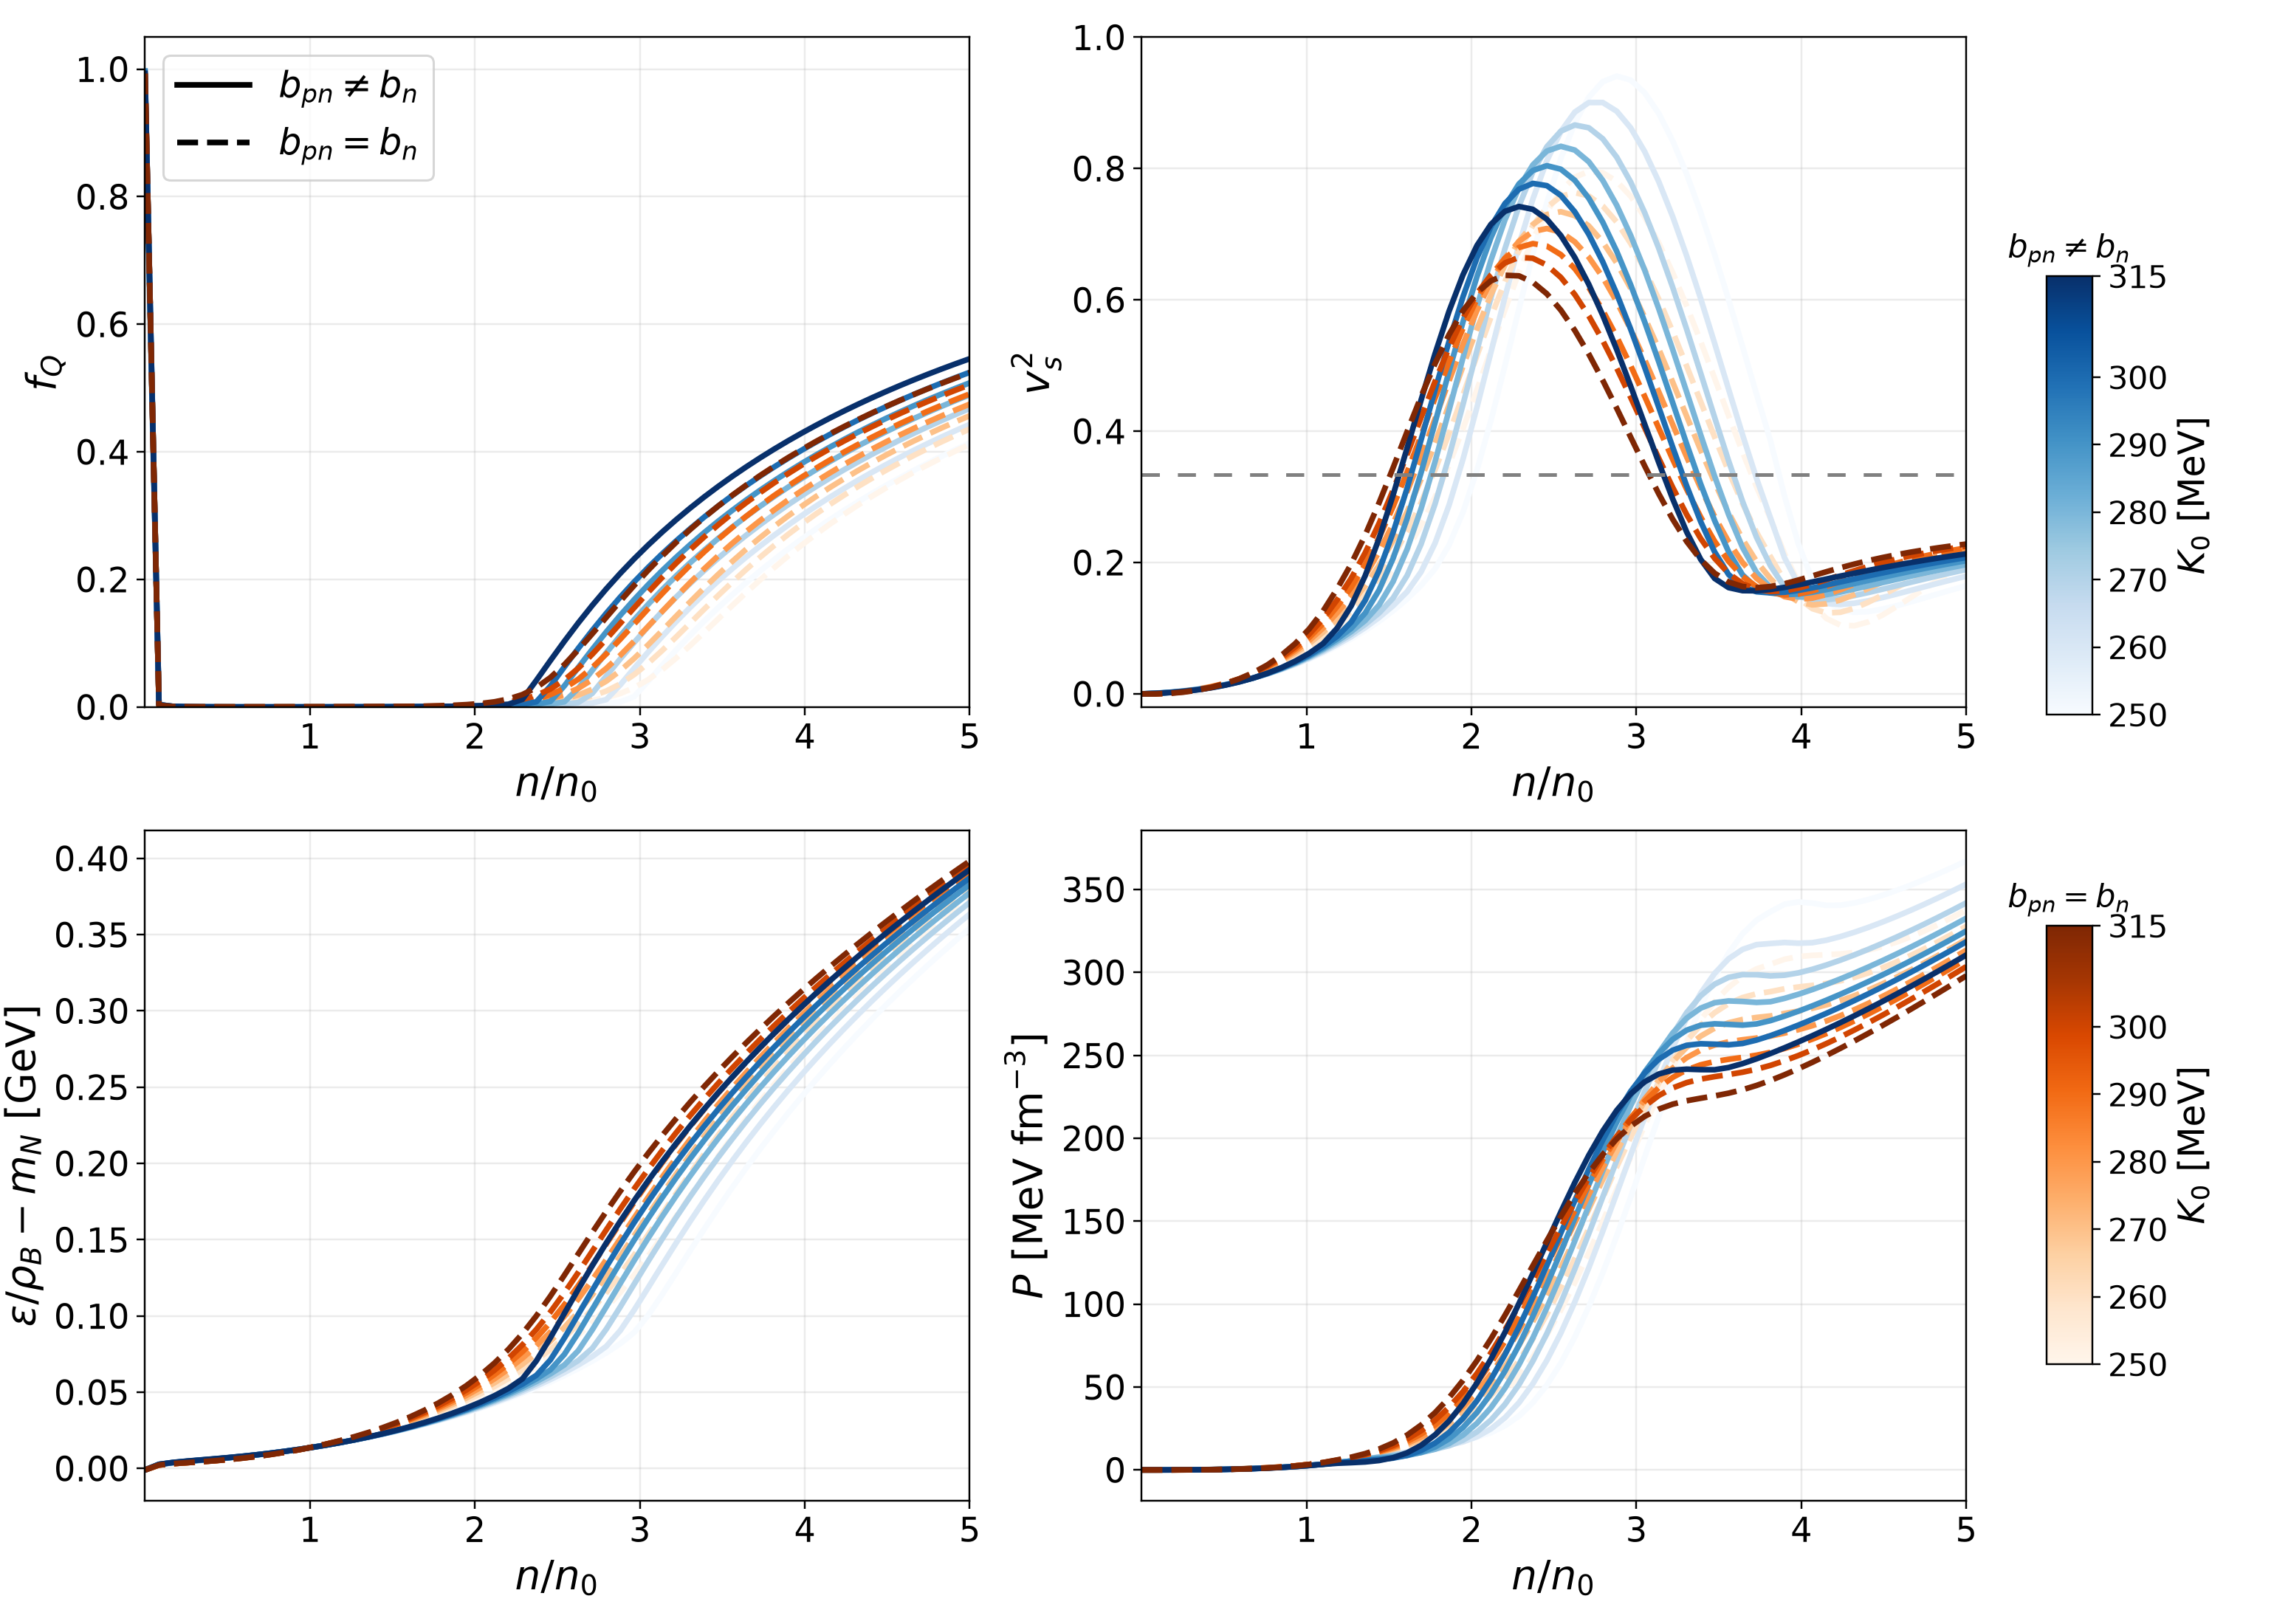

In [4]:
display(Image(filename=str(OUTPUT_DIR / 'clausius_branch_comparison_k0_overlay.png')))


### 2. Same-Color-Per-`K_0` Comparison

This version uses the **same color for the same `K_0`** in both branches, and only changes the line style:

- solid: `b_{pn} 
eq b_n`
- dashed: `b_{pn} = b_n`

This is usually the clearest option for direct pairwise comparison.


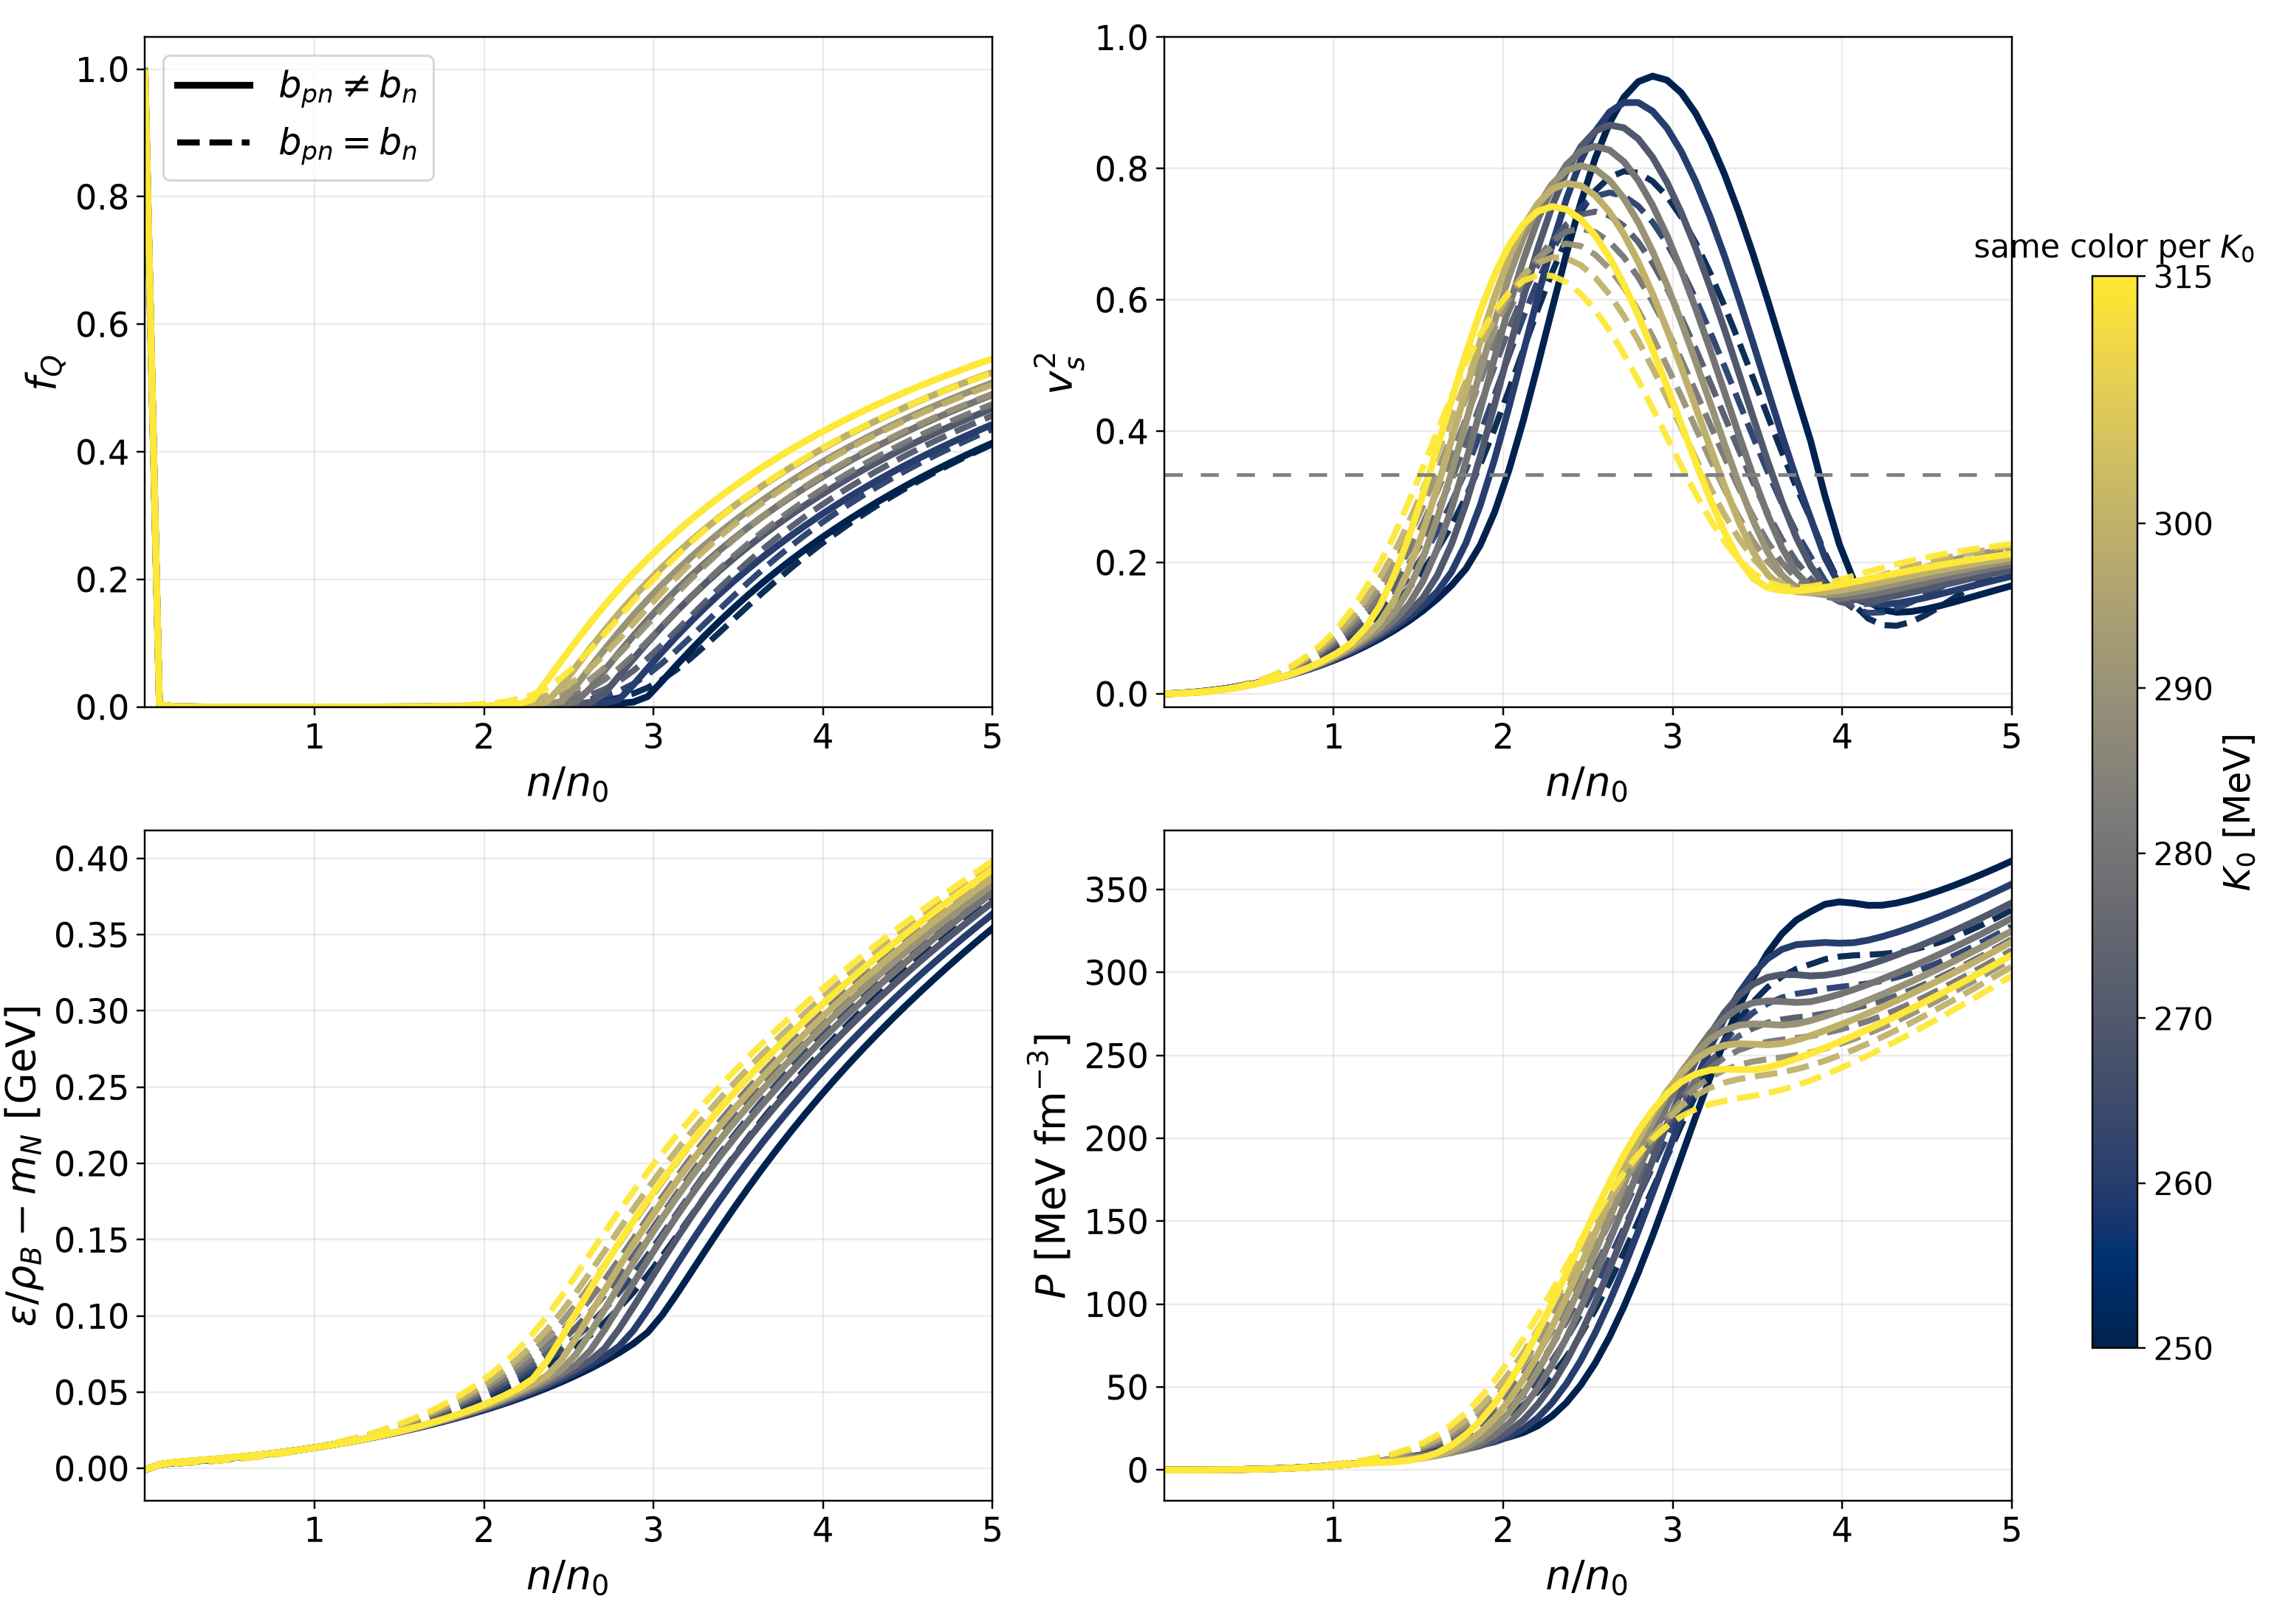

In [5]:
display(Image(filename=str(OUTPUT_DIR / 'clausius_branch_comparison_same_k0_colors.png')))


### 3. Reduced Comparison With Only `K_0 = 250, 280, 315`

This is the cleanest compact figure when all seven `K_0` curves are too crowded.


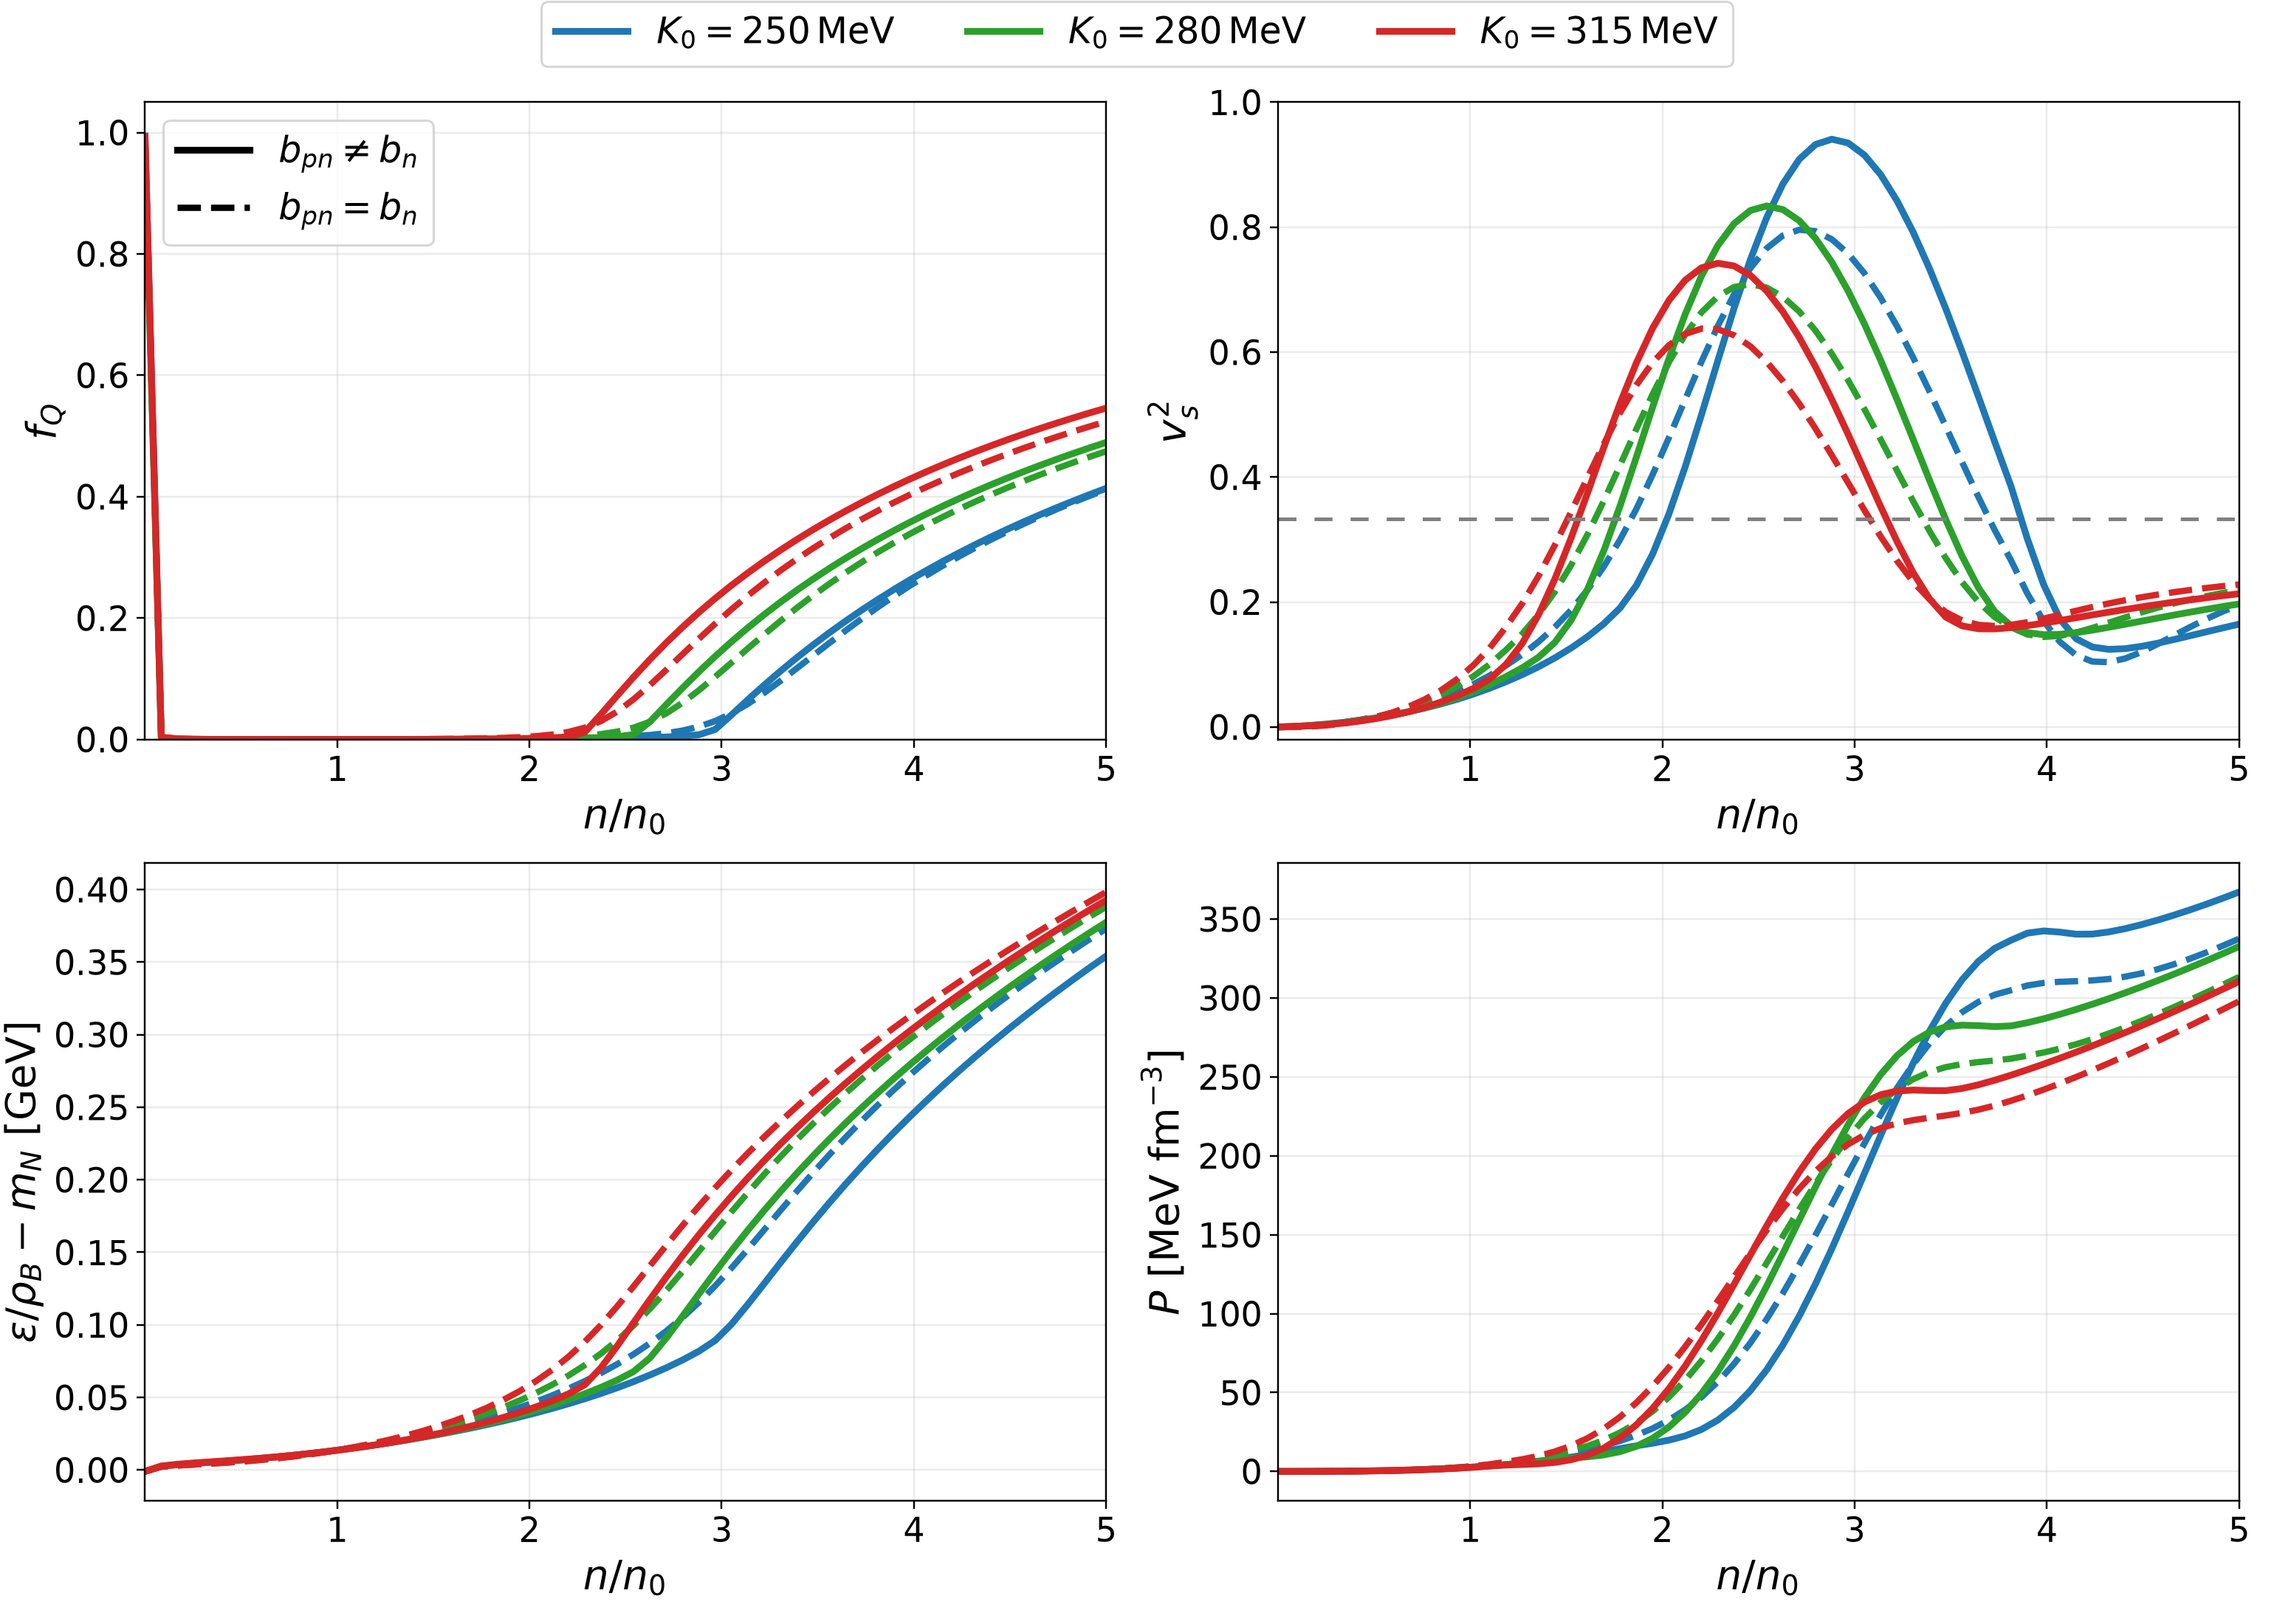

In [6]:
display(Image(filename=str(OUTPUT_DIR / 'clausius_branch_comparison_k0_250_280_315.png')))


## Notes

- The full Clausius scan results remain in the original result folders.
- This notebook only changes the **derivative reconstruction and plotting** from those saved tables.
- If the peak in `v_s^2` looks too sharp, increasing the smoothing `window` is the main control to test.
- The production choice saved here is `window = 29`, because it reduces the peak while keeping the curves readable.
